# Week 11 — Future Work 4 (FW4): BLIP-2 Architectural Comparison

**Dissertation:** Advance Multimodel Generative Artificial Intelligence — Controllable Image Captioning with Large Vision-Language Models
**Author:** Avinash Sahu  |  **Supervisor:** Varun Ojha

**Goal (interim report, FW4):** benchmark **LLaVA-1.6-Mistral-7B against BLIP-2** on the *same*
100-image COCO test set, under the *same* prompt conditions and the *same* BLEU-4 / CLIP metrics,
to isolate the effect of the **vision–language bridge**: BLIP-2 uses a **Q-Former**, LLaVA uses a
**linear projection**. Any difference under identical data and prompts points to the bridge (and
the size of the frozen language model) rather than to the evaluation setup.

Stays entirely on your existing **1,000-image** set (`data/processed/test.csv`, 100 test images)
and reuses your Week 1–8 conventions (paths, `' | '` caption format, BLEU/CLIP functions, seed 42,
results-table schema). BLIP-2 is cached to Drive on first load, exactly like your LLaVA cache.


In [1]:
# ── CELL 1 — Mount Google Drive ──────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted.')


Mounted at /content/drive
Drive mounted.


In [2]:
# ── CELL 2 — Install packages ─────────────────────────────────────────────
!pip install -q --upgrade accelerate
!pip install -q sentencepiece nltk
import nltk
nltk.download('punkt', quiet=True); nltk.download('wordnet', quiet=True)
import transformers
print(f'transformers : {transformers.__version__}')
print('Packages ready. No restart needed.')


transformers : 5.12.1
Packages ready. No restart needed.


In [3]:
# ── CELL 3 — Paths and config ─────────────────────────────────────────────
import os
BASE          = '/content/drive/MyDrive/dissertation_final'
PROCESSED_DIR = f'{BASE}/data/processed'          # SAME 1,000-image splits as Week 1
RESULTS_DIR   = f'{BASE}/results'
MODELS_DIR    = f'{BASE}/models'

# BLIP-2: 'Salesforce/blip2-opt-2.7b' (lighter, standard captioner) is the default.
# For stronger instruction-following on the prompt conditions you can switch to
# 'Salesforce/blip2-flan-t5-xl' — same code, just change this string.
BLIP2_MODEL_ID = 'Salesforce/blip2-opt-2.7b'
BLIP2_CACHE    = f'{MODELS_DIR}/blip2_cache'       # persisted to Drive like the LLaVA cache
SAVE_TO_DRIVE  = True                              # cache BLIP-2 weights to Drive on first load
RANDOM_SEED    = 42

os.makedirs(RESULTS_DIR, exist_ok=True); os.makedirs(MODELS_DIR, exist_ok=True)
print('Path check:')
print(f'  test.csv : {os.path.exists(f"{PROCESSED_DIR}/test.csv")} -> {PROCESSED_DIR}/test.csv')
print(f'  results/ : {os.path.exists(RESULTS_DIR)}')
print(f'  BLIP-2   : {BLIP2_MODEL_ID}  (Drive cache: {BLIP2_CACHE})')


Path check:
  test.csv : True -> /content/drive/MyDrive/dissertation_final/data/processed/test.csv
  results/ : True
  BLIP-2   : Salesforce/blip2-opt-2.7b  (Drive cache: /content/drive/MyDrive/dissertation_final/models/blip2_cache)


In [4]:
# ── CELL 4 — GPU check ────────────────────────────────────────────────────
import torch
if torch.cuda.is_available():
    print('GPU :', torch.cuda.get_device_name(0),
          f'| VRAM {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB',
          f'| CUDA {torch.version.cuda} | torch {torch.__version__}')
    print('BLIP-2 OPT-2.7B in float16 needs ~8 GB — fits comfortably on T4/A100.')
else:
    print('No GPU. Runtime -> Change runtime type -> GPU.')


GPU : NVIDIA A100-SXM4-40GB | VRAM 42.4 GB | CUDA 12.8 | torch 2.11.0+cu128
BLIP-2 OPT-2.7B in float16 needs ~8 GB — fits comfortably on T4/A100.


In [5]:
# ── CELL 5 — Imports ──────────────────────────────────────────────────────
import os, json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch
from PIL import Image
from tqdm import tqdm
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction
from transformers import Blip2Processor, Blip2ForConditionalGeneration, CLIPProcessor, CLIPModel
print('Imports done.')


Imports done.


In [6]:
# ── CELL 6 — Load BLIP-2 (Drive cache if present, else download + cache) ─
def load_blip2():
    load_from = BLIP2_CACHE if os.path.exists(f'{BLIP2_CACHE}/config.json') else BLIP2_MODEL_ID
    print(f'Loading BLIP-2 from: {load_from}')
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    processor = Blip2Processor.from_pretrained(load_from)
    model     = Blip2ForConditionalGeneration.from_pretrained(
        load_from, torch_dtype=torch.float16, device_map='auto', low_cpu_mem_usage=True)
    model.eval()
    if SAVE_TO_DRIVE and load_from == BLIP2_MODEL_ID:
        print(f'Caching BLIP-2 to Drive: {BLIP2_CACHE} (first run only)...')
        model.save_pretrained(BLIP2_CACHE); processor.save_pretrained(BLIP2_CACHE)
    print(f'Loaded on {next(model.parameters()).device} | dtype: {next(model.parameters()).dtype}')
    return processor, model

blip2_processor, blip2_model = load_blip2()
print('BLIP-2 ready.')


Loading BLIP-2 from: /content/drive/MyDrive/dissertation_final/models/blip2_cache


Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

Loaded on cuda:0 | dtype: torch.float32
BLIP-2 ready.


In [7]:
# ── CELL 7 — generate (BLIP-2) + BLEU/CLIP metrics (same metrics as Week 3) ─
def generate_caption_blip2(image, prompt=None, max_new_tokens=100):
    if prompt:
        inputs = blip2_processor(images=image, text=prompt, return_tensors='pt')
    else:
        inputs = blip2_processor(images=image, return_tensors='pt')
    inputs = {k: v.to(blip2_model.device) for k, v in inputs.items()}
    if 'pixel_values' in inputs:
        inputs['pixel_values'] = inputs['pixel_values'].to(torch.float16)
    with torch.no_grad():
        out = blip2_model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    text = blip2_processor.batch_decode(out, skip_special_tokens=True)[0].strip()
    if prompt and text.lower().startswith(prompt.lower()[:15]):  # strip echoed prompt if any
        text = text[len(prompt):].strip()
    return text

_clip_proc, _clip_model = None, None
def get_clip():
    global _clip_proc, _clip_model
    if _clip_model is None:
        _clip_proc  = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')
        _clip_model = CLIPModel.from_pretrained('openai/clip-vit-base-patch32').to(
            'cuda' if torch.cuda.is_available() else 'cpu').eval()
    return _clip_proc, _clip_model

def _txt(x):
    # coerce NaN / float / None to a safe lowercase token list
    return ('' if (x is None or (isinstance(x, float))) else str(x)).lower().split()

def compute_sentence_bleu(gen, refs):
    s = SmoothingFunction().method1
    return round(sentence_bleu([_txt(r) for r in refs], _txt(gen), smoothing_function=s), 4)

def compute_bleu(generated, references):
    s = SmoothingFunction().method1
    hyps = [_txt(g) for g in generated]
    refs = [[_txt(r) for r in rs] for rs in references]
    return {'bleu_1': round(corpus_bleu(refs, hyps, weights=(1,0,0,0), smoothing_function=s), 4),
            'bleu_4': round(corpus_bleu(refs, hyps, weights=(.25,.25,.25,.25), smoothing_function=s), 4)}

def compute_clip_scores_batch(images, captions, batch_size=16):
    proc, mdl = get_clip(); dev, scores = next(mdl.parameters()).device, []
    for i in range(0, len(images), batch_size):
        inp = proc(text=captions[i:i+batch_size], images=images[i:i+batch_size],
                   return_tensors='pt', padding=True, truncation=True, max_length=77)
        inp = {k: v.to(dev) for k, v in inp.items()}
        with torch.no_grad():
            o = mdl(**inp)
            ie = o.image_embeds / o.image_embeds.norm(dim=-1, keepdim=True)
            te = o.text_embeds  / o.text_embeds.norm(dim=-1,  keepdim=True)
            scores.extend((ie*te).sum(dim=-1).tolist())
    return [round(s, 4) for s in scores]

# smoke test
_df = pd.read_csv(f'{PROCESSED_DIR}/test.csv')
_img = Image.open(_df.iloc[0]['img_path']).convert('RGB')
print('BLIP-2 unconditional:', generate_caption_blip2(_img)[:120])
print('metrics ready.')


BLIP-2 unconditional: a boy in a red shirt
metrics ready.


In [8]:
# ── CELL 8 — Conditions (same prompt texts as LLaVA in Weeks 3–4) ────────
# baseline = BLIP-2's native (unconditional) captioning; the rest use identical
# prompt strings to LLaVA so the only variable is the model / bridge.
HARD = {
    'object_focus':   'List the main objects visible in this image and describe each briefly.',
    'style_formal':   'Write a formal, precise description of this image as it would appear in a museum catalogue.',
    'style_simple':   'Describe this image using simple words a child could understand. Keep it to one sentence.',
    'attribute_rich': 'Describe this image with specific attention to colours, textures, sizes, and spatial relationships between objects.',
    'action_focus':   'Describe what is happening in this image. Focus on any actions, movements, or events taking place.',
}
EXPERT = {
    'expert_vision': ('You are an expert computer vision researcher annotating images for a large-scale '
                      'dataset. Provide a precise, comprehensive description of this image covering: main '
                      'objects, their attributes, spatial relationships, background context, and any notable '
                      'details a human annotator would record.'),
    'expert_domain': ('You are a professional image captioning specialist with extensive experience in visual '
                      'content analysis. Generate a high-quality, factually accurate caption for this image that '
                      'captures the most important visual information. Be specific about object types, colours, '
                      'quantities, and positions.'),
    'expert_coco':   ('You are an expert annotator working on the MS COCO dataset. Write a single descriptive '
                      'sentence that accurately describes the main subject and action in this image, following '
                      'the style of professional COCO human annotations. Be concise, accurate, and grounded only '
                      'in what is visible.'),
}
CONDITIONS = {'baseline': None}
CONDITIONS.update(HARD); CONDITIONS.update(EXPERT)
print(f'{len(CONDITIONS)} BLIP-2 conditions:', ', '.join(CONDITIONS))


9 BLIP-2 conditions: baseline, object_focus, style_formal, style_simple, attribute_rich, action_focus, expert_vision, expert_domain, expert_coco


In [9]:
# ── CELL 9 — Run BLIP-2 over the 100-image test set for each condition ───
test_df = pd.read_csv(f'{PROCESSED_DIR}/test.csv')
for cond, prompt in CONDITIONS.items():
    out_csv = f'{RESULTS_DIR}/week11_fw4_blip2_{cond}.csv'
    if os.path.exists(out_csv):
        print(f'[skip] {cond} done -> {os.path.basename(out_csv)}'); continue
    print(f'\n=== BLIP-2 | {cond} ===')
    records, gens, imgs = [], [], []
    for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc=cond):
        image = Image.open(row['img_path']).convert('RGB')
        gen   = generate_caption_blip2(image, prompt=prompt)
        refs  = row['captions'].split(' | ')
        records.append({'image_id': row['image_id'], 'img_path': row['img_path'],
                        'generated': gen, 'references': row['captions'],
                        'bleu4': compute_sentence_bleu(gen, refs)})
        gens.append(gen); imgs.append(image)
    for r, c in zip(records, compute_clip_scores_batch(imgs, gens)):
        r['clip_score'] = c
    pd.DataFrame(records).to_csv(out_csv, index=False)
    print(f'  saved -> {out_csv}')
print('\nAll BLIP-2 conditions complete.')


[skip] baseline done -> week11_fw4_blip2_baseline.csv
[skip] object_focus done -> week11_fw4_blip2_object_focus.csv
[skip] style_formal done -> week11_fw4_blip2_style_formal.csv
[skip] style_simple done -> week11_fw4_blip2_style_simple.csv
[skip] attribute_rich done -> week11_fw4_blip2_attribute_rich.csv
[skip] action_focus done -> week11_fw4_blip2_action_focus.csv
[skip] expert_vision done -> week11_fw4_blip2_expert_vision.csv
[skip] expert_domain done -> week11_fw4_blip2_expert_domain.csv
[skip] expert_coco done -> week11_fw4_blip2_expert_coco.csv

All BLIP-2 conditions complete.


In [10]:
# ── CELL 10 — Aggregate BLIP-2 results (same schema as Week 8) ───────────
rows = []
for cond in CONDITIONS:
    p = f'{RESULTS_DIR}/week11_fw4_blip2_{cond}.csv'
    if not os.path.exists(p): continue
    df = pd.read_csv(p)
    df['generated'] = df['generated'].fillna('')
    bleu = compute_bleu(df['generated'].tolist(), [str(r).split(' | ') for r in df['references']])
    rows.append({'Technique': cond, 'BLEU-1': bleu['bleu_1'], 'BLEU-4': bleu['bleu_4'],
                 'CLIP score (mean)': round(df['clip_score'].mean(), 4),
                 'CLIP score (std)':  round(df['clip_score'].std(),  4), 'N': len(df)})
blip2_tbl = pd.DataFrame(rows)
base = blip2_tbl[blip2_tbl['Technique'] == 'baseline']
if len(base):
    b4, bc = base['BLEU-4'].values[0], base['CLIP score (mean)'].values[0]
    blip2_tbl['Delta BLEU-4']     = (blip2_tbl['BLEU-4'] - b4).round(4)
    blip2_tbl['Delta CLIP score'] = (blip2_tbl['CLIP score (mean)'] - bc).round(4)
blip2_tbl.to_csv(f'{RESULTS_DIR}/FINAL_results_fw4_blip2.csv', index=False)
print('Saved: FINAL_results_fw4_blip2.csv\n')
print('='*80); print('FW4 — BLIP-2 (Q-Former bridge), test n=100'); print('='*80)
print(blip2_tbl.to_string(index=False))


Saved: FINAL_results_fw4_blip2.csv

FW4 — BLIP-2 (Q-Former bridge), test n=100
     Technique  BLEU-1  BLEU-4  CLIP score (mean)  CLIP score (std)   N  Delta BLEU-4  Delta CLIP score
      baseline  0.7333  0.3649             0.3009            0.0360 100        0.0000             0.000
  object_focus  0.0000  0.0000             0.1939            0.0165 100       -0.3649            -0.107
  style_formal  0.0000  0.0000             0.1939            0.0165 100       -0.3649            -0.107
  style_simple  0.0000  0.0000             0.1939            0.0165 100       -0.3649            -0.107
attribute_rich  0.0000  0.0000             0.1939            0.0165 100       -0.3649            -0.107
  action_focus  0.0000  0.0000             0.1939            0.0165 100       -0.3649            -0.107
 expert_vision  0.0000  0.0000             0.1939            0.0165 100       -0.3649            -0.107
 expert_domain  0.0000  0.0000             0.1939            0.0165 100       -0.3649    

In [11]:
# ── CELL 11 — Side-by-side: LLaVA (linear proj.) vs BLIP-2 (Q-Former) ────
# Loads your LLaVA ablation table and matches conditions by name.
llava_path = f'{RESULTS_DIR}/FINAL_results_table.csv'
if os.path.exists(llava_path):
    llava = pd.read_csv(llava_path)
    # normalise technique keys on both sides
    def key(s): return (str(s).lower().replace('baseline (zero-shot llava)', 'baseline')
                        .replace(' ', '_'))
    llava['key']  = llava['Technique'].map(key)
    bl = blip2_tbl.copy(); bl['key'] = bl['Technique'].map(key)
    bcol = 'BLEU-4'; ccol = 'CLIP score (mean)'
    m = llava.merge(bl, on='key', suffixes=(' [LLaVA]', ' [BLIP-2]'), how='inner')
    show = [c for c in ['key', f'{bcol} [LLaVA]', f'{bcol} [BLIP-2]',
            f'{ccol} [LLaVA]', f'{ccol} [BLIP-2]'] if c in m.columns]
    print('LLaVA (linear projection)  vs  BLIP-2 (Q-Former) — matching conditions:')
    print(m[show].to_string(index=False))
    m[show].to_csv(f'{RESULTS_DIR}/FINAL_results_fw4_comparison.csv', index=False)
    print('\nSaved: FINAL_results_fw4_comparison.csv')
else:
    print('LLaVA FINAL_results_table.csv not found — run Week 8 to enable the comparison.')
    print('BLIP-2 standalone results are in FINAL_results_fw4_blip2.csv.')


LLaVA (linear projection)  vs  BLIP-2 (Q-Former) — matching conditions:
     key  BLEU-4 [LLaVA]  BLEU-4 [BLIP-2]  CLIP score (mean) [LLaVA]  CLIP score (mean) [BLIP-2]
baseline          0.0213           0.3649                     0.3173                      0.3009

Saved: FINAL_results_fw4_comparison.csv


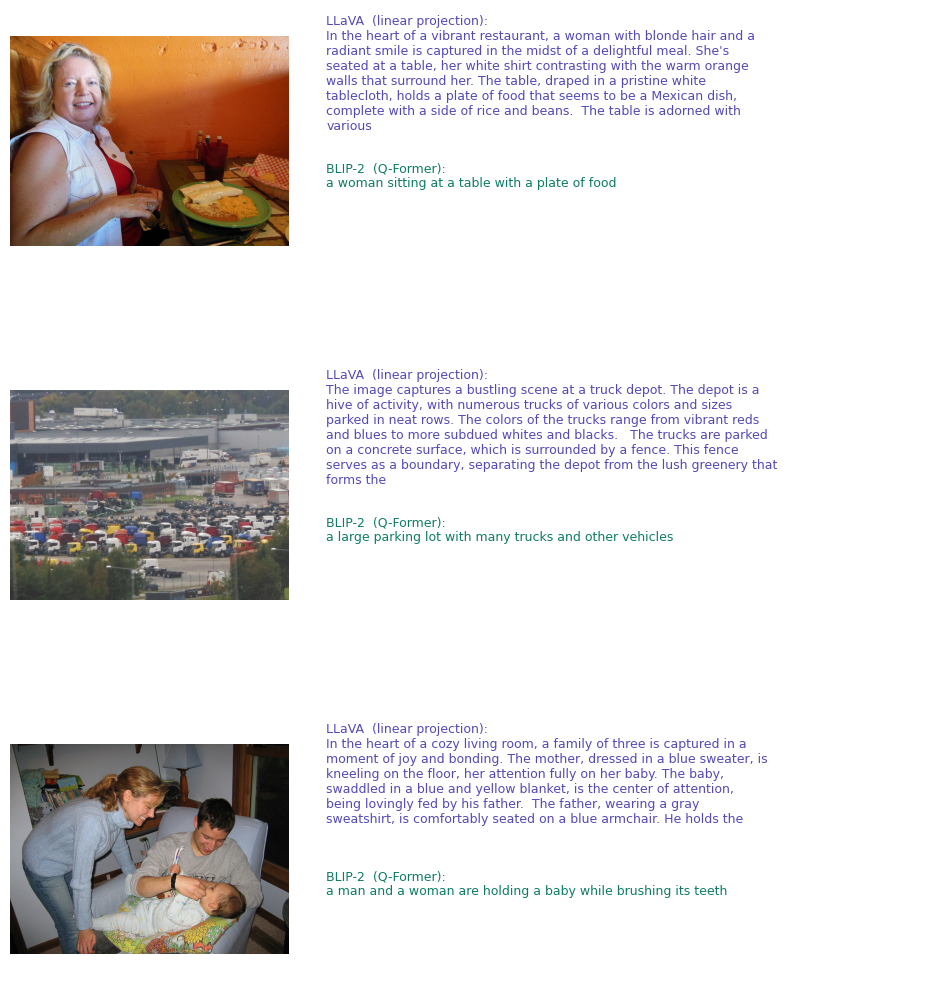

Saved figure: /content/drive/MyDrive/dissertation_final/results/week11_fw4_qualitative_examples.png


In [12]:
# -- CELL 11b -- Qualitative side-by-side (no overlap): LLaVA vs BLIP-2 --
import textwrap
llava_csv = f'{RESULTS_DIR}/week3_baseline.csv'
blip_csv  = f'{RESULTS_DIR}/week11_fw4_blip2_baseline.csv'
if os.path.exists(llava_csv) and os.path.exists(blip_csv):
    L = pd.read_csv(llava_csv)[['image_id','img_path','generated']].rename(columns={'generated':'llava'})
    B = pd.read_csv(blip_csv)[['image_id','generated']].rename(columns={'generated':'blip2'})
    M = L.merge(B, on='image_id')
    M['blip2'] = M['blip2'].fillna(''); M = M[M['blip2'].astype(str).str.strip() != '']
    ex = M.sample(min(3, len(M)), random_state=RANDOM_SEED)

    WRAP = 70
    n = len(ex)
    fig, axes = plt.subplots(n, 1, figsize=(12, 4.2 * n))
    if n == 1:
        axes = [axes]
    for ax, (_, r) in zip(axes, ex.iterrows()):
        ax.axis('off')
        axim = ax.inset_axes([0.0, 0.0, 0.30, 1.0])          # image on the left 30%
        axim.imshow(Image.open(r['img_path']).convert('RGB')); axim.axis('off')
        llava_txt = "LLaVA  (linear projection):\n" + textwrap.fill(str(r['llava']), WRAP)
        blip_txt  = "BLIP-2  (Q-Former):\n" + textwrap.fill(str(r['blip2']), WRAP)
        ax.text(0.34, 0.98, llava_txt, fontsize=9, va='top', ha='left',
                transform=ax.transAxes, color='#534AB7')
        ax.text(0.34, 0.42, blip_txt,  fontsize=9, va='top', ha='left',
                transform=ax.transAxes, color='#0E7C66')
    plt.subplots_adjust(hspace=0.35)
    out = f'{RESULTS_DIR}/week11_fw4_qualitative_examples.png'
    plt.savefig(out, dpi=150, bbox_inches='tight'); plt.show()
    print('Saved figure:', out)
else:
    print('Need week3_baseline.csv (LLaVA) and week11_fw4_blip2_baseline.csv (BLIP-2) for the side-by-side.')


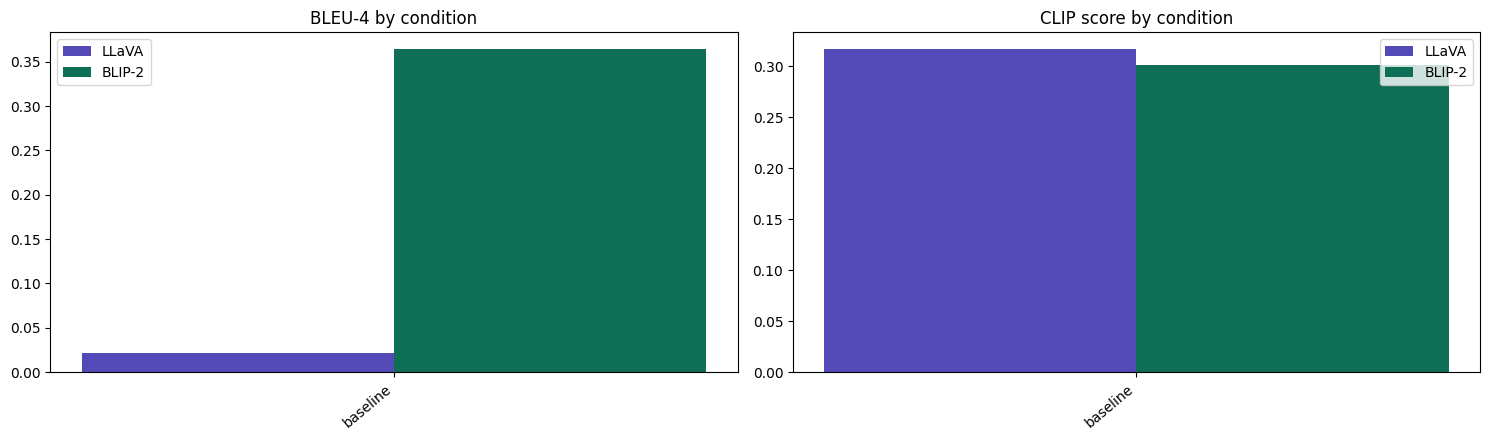

Saved figure: /content/drive/MyDrive/dissertation_final/results/week11_fw4_llava_vs_blip2.png

FW4 complete. Last future-work item: FW5 (hallucination-rate metric).


In [13]:
# ── CELL 12 — Grouped bar chart: LLaVA vs BLIP-2 by condition ────────────
if os.path.exists(llava_path) and len(m):
    import numpy as np
    labels = m['key'].tolist()
    x = np.arange(len(labels)); w = 0.35
    fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
    ax[0].bar(x-w/2, m[f'BLEU-4 [LLaVA]'], w, label='LLaVA', color='#534AB7')
    ax[0].bar(x+w/2, m[f'BLEU-4 [BLIP-2]'], w, label='BLIP-2', color='#0F6E56')
    ax[0].set_title('BLEU-4 by condition'); ax[0].set_xticks(x); ax[0].set_xticklabels(labels, rotation=40, ha='right'); ax[0].legend()
    ax[1].bar(x-w/2, m[f'CLIP score (mean) [LLaVA]'], w, label='LLaVA', color='#534AB7')
    ax[1].bar(x+w/2, m[f'CLIP score (mean) [BLIP-2]'], w, label='BLIP-2', color='#0F6E56')
    ax[1].set_title('CLIP score by condition'); ax[1].set_xticks(x); ax[1].set_xticklabels(labels, rotation=40, ha='right'); ax[1].legend()
    plt.tight_layout()
    out = f'{RESULTS_DIR}/week11_fw4_llava_vs_blip2.png'
    plt.savefig(out, dpi=150, bbox_inches='tight'); plt.show()
    print('Saved figure:', out)
print('\nFW4 complete. Last future-work item: FW5 (hallucination-rate metric).')
